In [1]:
import torch 
import os
import matplotlib.pyplot as plt
import numpy as np
from sklearn.mixture import GaussianMixture
from scipy.stats import norm
from scipy.optimize import fsolve

# result_dir = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_w_flow_lifespan_alpha/TPGS/results_nvidia_w_flow_lifespan_alpha"
# result_dir = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_w_flow_exp_lifespan_small_alpha/TPGS/results_nvidia_w_flow_exp_lifespan_small_alpha"
# result_dir = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/optimize-gaussian/src_old/results_nvidia_gt_cam_pred_mask_no_limit"
result_dir = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_wo_transient/TPGS/results_nvidia_wo_transient/"
scene_names = os.listdir(result_dir)

In [2]:
def fit_gaussian_mixture(lifespan_data, n_components=2, random_state=42):
    data = lifespan_data.reshape(-1, 1)
    
    gmm = GaussianMixture(n_components=n_components, random_state=random_state)
    gmm.fit(data)
    
    means = gmm.means_.flatten()
    stds = np.sqrt(gmm.covariances_).flatten()
    weights = gmm.weights_
    
    sorted_indices = np.argsort(means)
    means = means[sorted_indices]
    stds = stds[sorted_indices]
    weights = weights[sorted_indices]
    
    return gmm, means, stds, weights


def find_local_minimum_between_means(means, stds, weights, num=2000):
    # assume means are sorted ascending
    mu1, mu2 = means[0], means[1]
    if mu1 == mu2:
        return None, None
    left = mu1
    right = mu2
    x = np.linspace(left, right, num)
    pdf_sum = weights[0] * norm.pdf(x, means[0], stds[0]) + weights[1] * norm.pdf(x, means[1], stds[1])
    idx_min = np.argmin(pdf_sum)
    return x[idx_min], pdf_sum[idx_min]

def visualize_gmm_lifespan(lifespan_data, scene_name="", bins=50):
    gmm, means, stds, weights = fit_gaussian_mixture(lifespan_data)
    
    # find local minimum (valley) between the two component means and use it as threshold
    valley_x, valley_y = find_local_minimum_between_means(means, stds, weights)
    if valley_x is not None:
        print(f"Local minimum between means: x={valley_x:.4f}, pdf={valley_y:.6f}")
    else:
        print("Could not compute local minimum (means identical?)")
    
    plt.figure(figsize=(12, 8))
    
    counts, bin_edges, patches = plt.hist(lifespan_data, bins=bins, density=True, 
                                         alpha=0.6, color='lightblue', edgecolor='black', 
                                         label='Lifespan Distribution')
    
    x_range = np.linspace(lifespan_data.min(), lifespan_data.max(), 1000)
    
    gmm_pdf = np.exp(gmm.score_samples(x_range.reshape(-1, 1)))
    plt.plot(x_range, gmm_pdf, 'r-', linewidth=3, label='GMM Fit', alpha=0.8)
    
    component1_pdf = weights[0] * norm.pdf(x_range, means[0], stds[0])
    component2_pdf = weights[1] * norm.pdf(x_range, means[1], stds[1])
    
    plt.plot(x_range, component1_pdf, '--', linewidth=2, color='green', 
             label=f'Component 1: μ={means[0]:.3f}, σ={stds[0]:.3f}')
    plt.plot(x_range, component2_pdf, '--', linewidth=2, color='orange', 
             label=f'Component 2: μ={means[1]:.3f}, σ={stds[1]:.3f}')
    
    # plot valley (local minimum) as the threshold
    if valley_x is not None:
        plt.plot(valley_x, valley_y, 'ks', markersize=8, label=f'Local minimum threshold: x={valley_x:.3f}')
        plt.axvline(x=valley_x, color='black', linestyle='--', alpha=0.8)
        plt.annotate(f'x={valley_x:.3f}', xy=(valley_x, valley_y), xytext=(10, -30),
                     textcoords='offset points', bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7),
                     arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0'))
    
    plt.xlabel('Lifespan Value')
    plt.ylabel('Probability Density')
    plt.title(f'Gaussian Mixture Model Analysis - {scene_name}')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()
    
    return gmm, means, stds, weights, (valley_x, valley_y)

def analyze_lifespan_with_temporal_center(lifespan: torch.Tensor, temporal_center: torch.Tensor, scene_name: str = "", enable_gmm: bool = True):
    if isinstance(lifespan, torch.Tensor):
        lifespan_np = lifespan.numpy()
    else:
        lifespan_np = lifespan
    
    if isinstance(temporal_center, torch.Tensor):
        temporal_center_np = temporal_center.numpy()
    else:
        temporal_center_np = temporal_center
    
    lifespan_hist_counts, lifespan_bin_edges = np.histogram(lifespan_np, bins=50)
    lifespan_max_bin_idx = np.argmax(lifespan_hist_counts)
    lifespan_max_bin_left = lifespan_bin_edges[lifespan_max_bin_idx]
    lifespan_max_bin_right = lifespan_bin_edges[lifespan_max_bin_idx + 1]
    
    lifespan_mask = (lifespan_np >= lifespan_max_bin_left) & (lifespan_np < lifespan_max_bin_right)
    temporal_center_in_lifespan_max_bin = temporal_center_np[lifespan_mask]
    
    temporal_hist_counts, temporal_bin_edges = np.histogram(temporal_center_np, bins=50)
    temporal_max_bin_idx = np.argmax(temporal_hist_counts)
    temporal_max_bin_left = temporal_bin_edges[temporal_max_bin_idx]
    temporal_max_bin_right = temporal_bin_edges[temporal_max_bin_idx + 1]
    
    temporal_mask = (temporal_center_np >= temporal_max_bin_left) & (temporal_center_np < temporal_max_bin_right)
    lifespan_in_temporal_max_bin = lifespan_np[temporal_mask]
    
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Lifespan & Temporal Center Analysis - {scene_name}', fontsize=14)
    
    axes[0, 0].hist(lifespan_np, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
    axes[0, 0].axvline(x=lifespan_max_bin_left, color='red', linestyle='--', alpha=0.8, label=f'Max freq bin')
    axes[0, 0].axvline(x=lifespan_max_bin_right, color='red', linestyle='--', alpha=0.8)
    axes[0, 0].set_title('Lifespan Histogram')
    axes[0, 0].set_xlabel('Lifespan Value')
    axes[0, 0].set_ylabel('Frequency')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].legend()
    
    if len(temporal_center_in_lifespan_max_bin) > 0:
        axes[0, 1].hist(temporal_center_in_lifespan_max_bin, bins=30, alpha=0.7, color='orange', edgecolor='black')
        axes[0, 1].set_title(f'Temporal Center in Max Lifespan Bin\n[{lifespan_max_bin_left:.3f}, {lifespan_max_bin_right:.3f})')
        axes[0, 1].set_xlabel('Temporal Center Value')
        axes[0, 1].set_ylabel('Frequency')
        axes[0, 1].grid(True, alpha=0.3)
    else:
        axes[0, 1].text(0.5, 0.5, 'No data in max bin', ha='center', va='center', transform=axes[0, 1].transAxes)
        axes[0, 1].set_title('Temporal Center in Max Lifespan Bin')
    
    axes[1, 0].hist(temporal_center_np, bins=50, alpha=0.7, color='lightcoral', edgecolor='black')
    axes[1, 0].axvline(x=temporal_max_bin_left, color='blue', linestyle='--', alpha=0.8, label=f'Max freq bin')
    axes[1, 0].axvline(x=temporal_max_bin_right, color='blue', linestyle='--', alpha=0.8)
    axes[1, 0].set_title('Temporal Center Histogram')
    axes[1, 0].set_xlabel('Temporal Center Value')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].grid(True, alpha=0.3)
    axes[1, 0].legend()
    
    if len(lifespan_in_temporal_max_bin) > 0:
        axes[1, 1].hist(lifespan_in_temporal_max_bin, bins=30, alpha=0.7, color='green', edgecolor='black')
        axes[1, 1].set_title(f'Lifespan in Max Temporal Center Bin\n[{temporal_max_bin_left:.3f}, {temporal_max_bin_right:.3f})')
        axes[1, 1].set_xlabel('Lifespan Value')
        axes[1, 1].set_ylabel('Frequency')
        axes[1, 1].grid(True, alpha=0.3)
    else:
        axes[1, 1].text(0.5, 0.5, 'No data in max bin', ha='center', va='center', transform=axes[1, 1].transAxes)
        axes[1, 1].set_title('Lifespan in Max Temporal Center Bin')
    
    plt.tight_layout()
    plt.show()
    
    if enable_gmm:
        visualize_gmm_lifespan(lifespan_np, scene_name)
    
    return lifespan_np, temporal_center_np


Processing scene: Skating
tensor(32.4358)


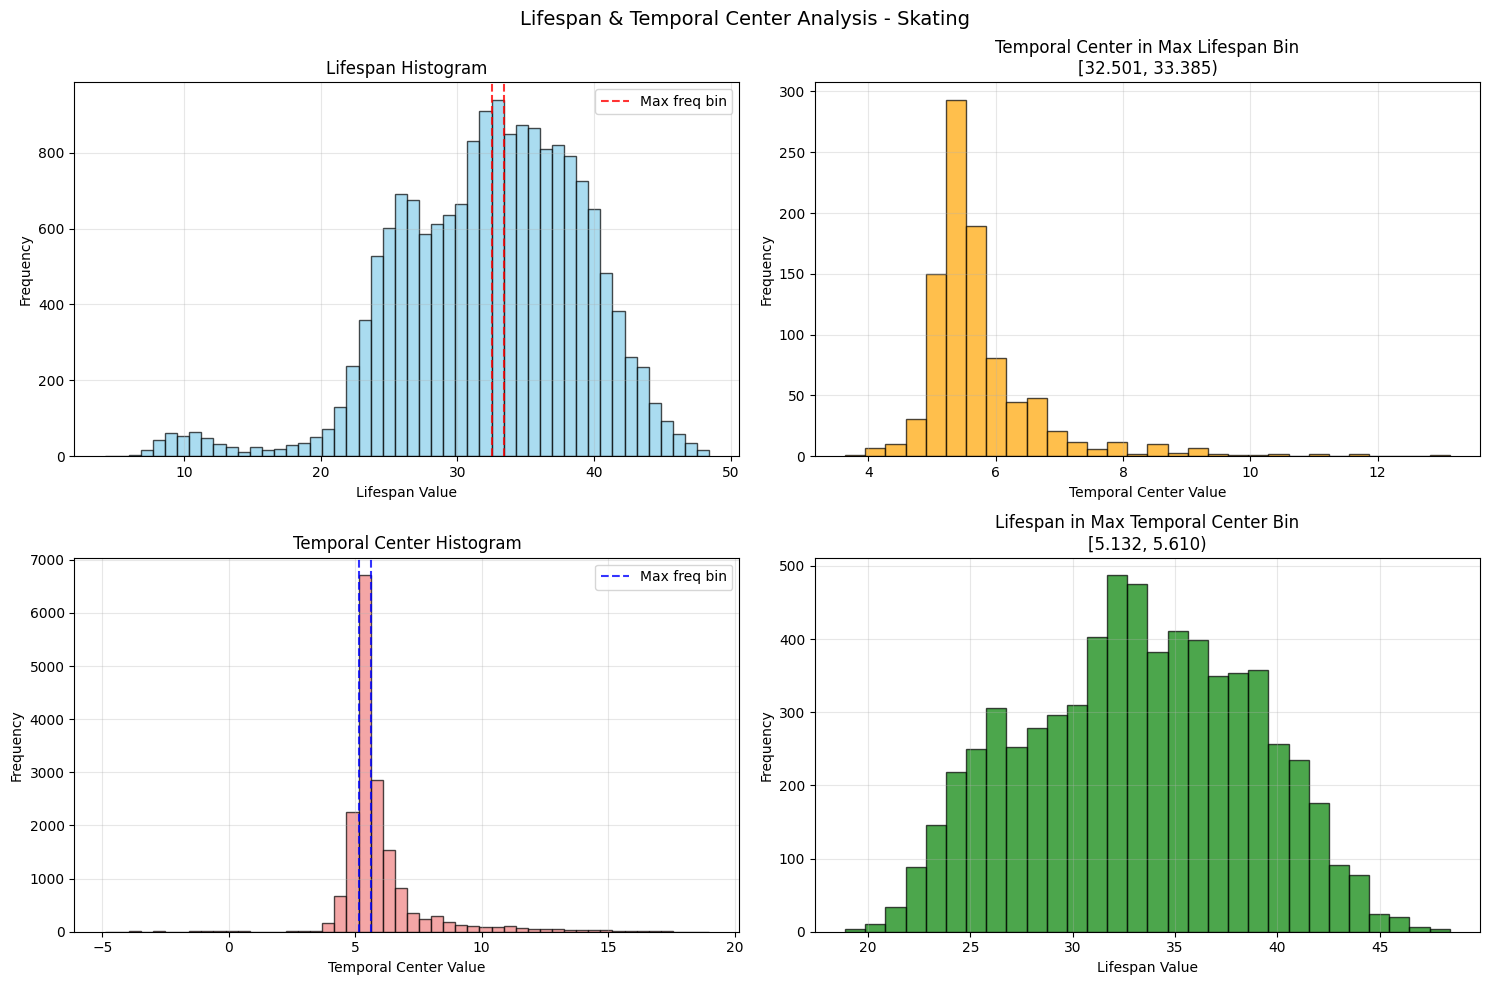

Local minimum between means: x=28.0680, pdf=0.038541


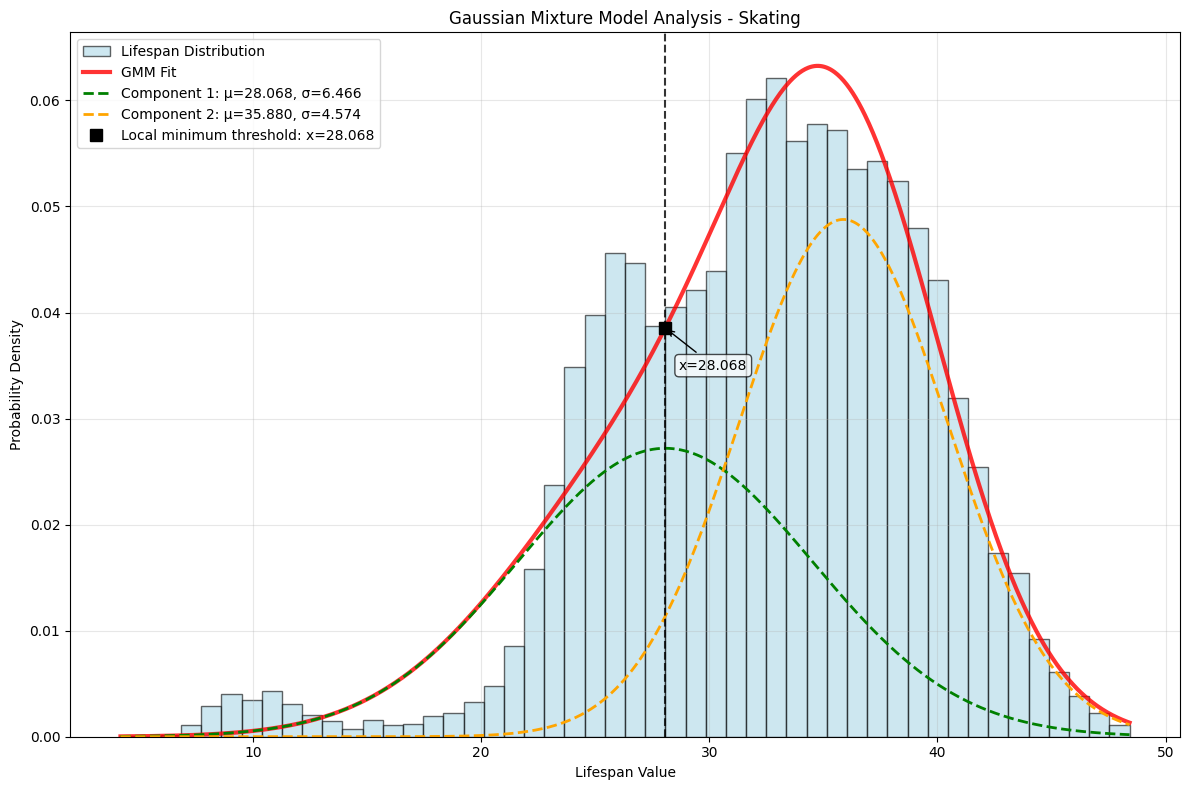


Processing scene: Playground
tensor(24.7198)


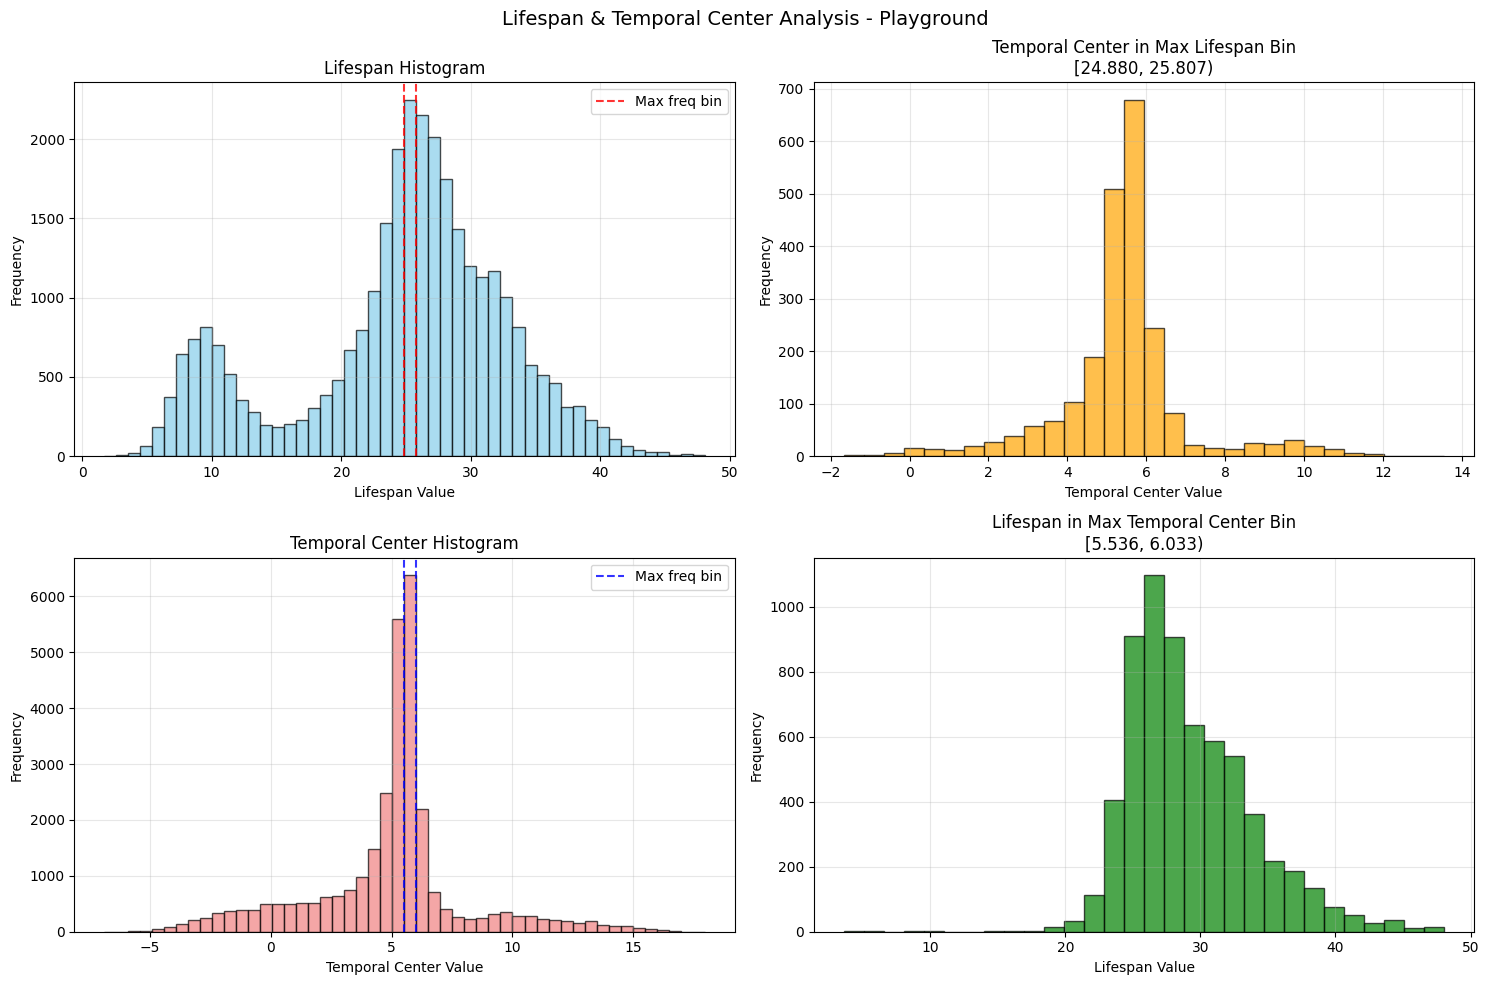

Local minimum between means: x=14.9151, pdf=0.005605


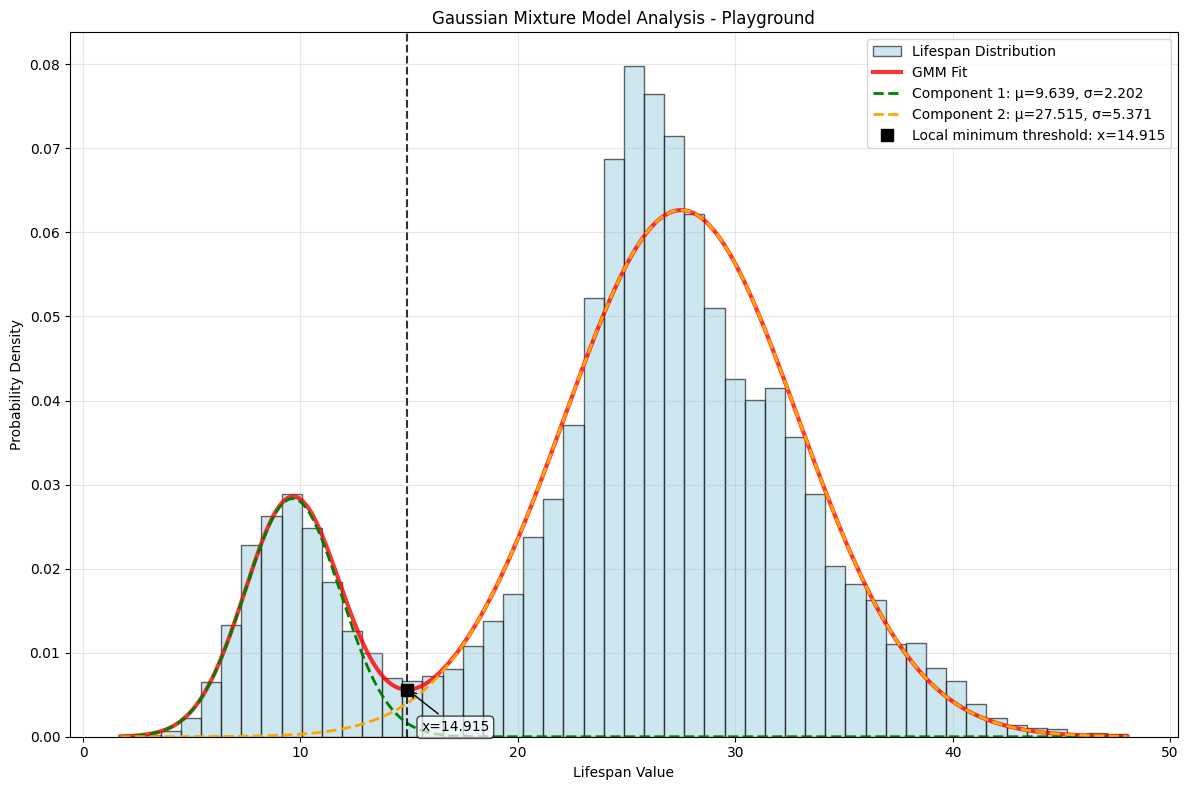


Processing scene: Balloon2
tensor(25.1737)


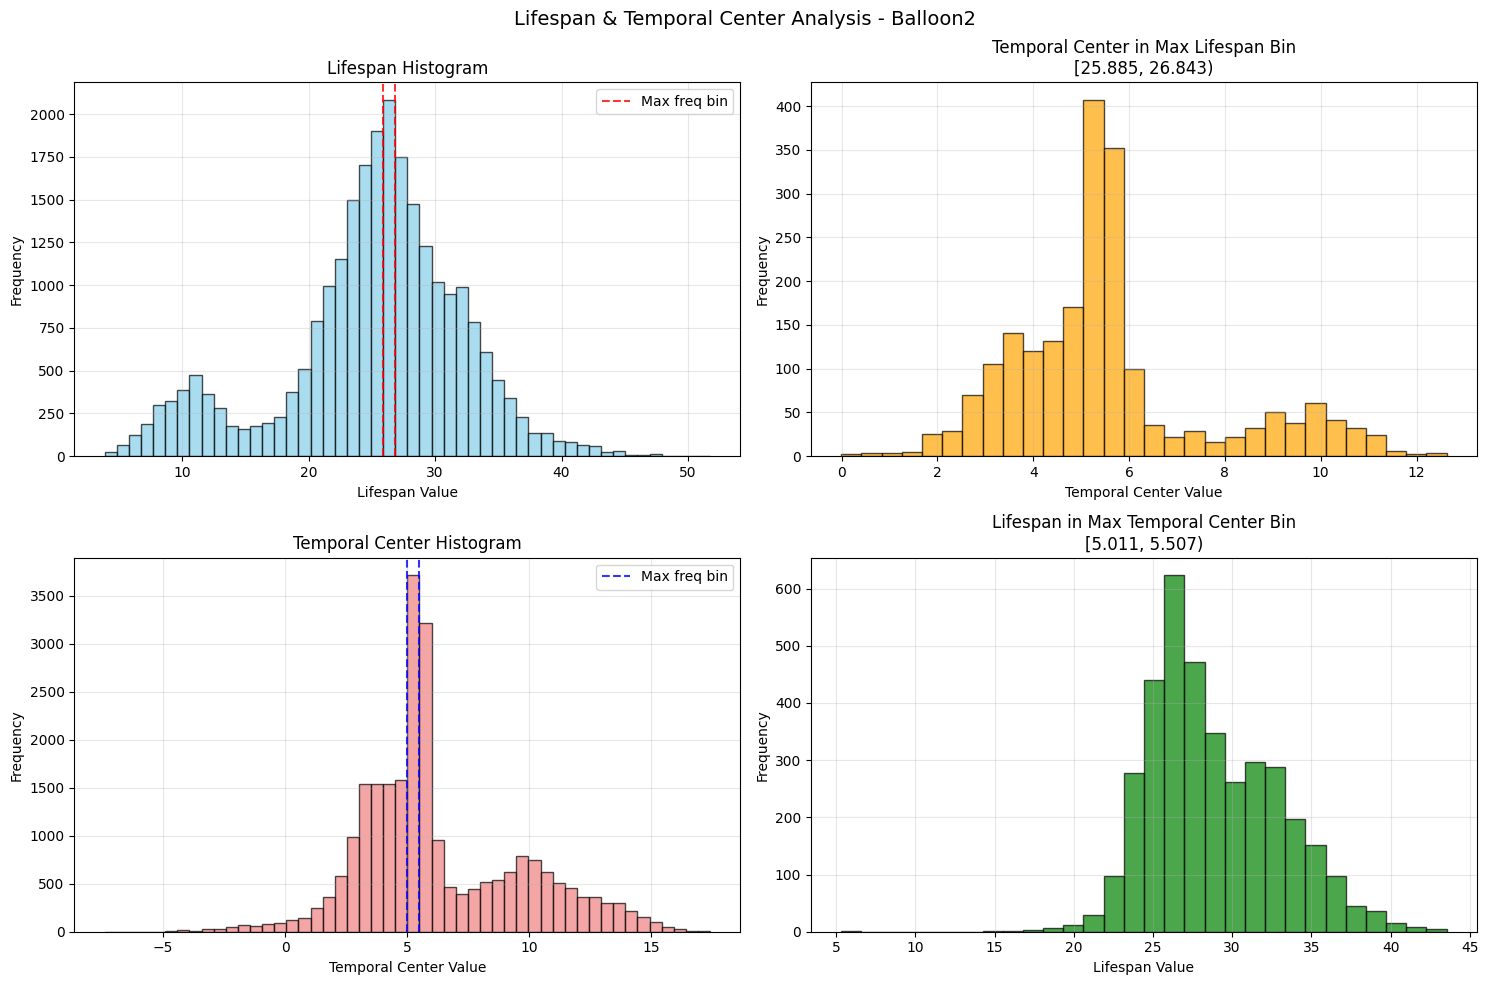

Local minimum between means: x=15.0493, pdf=0.007452


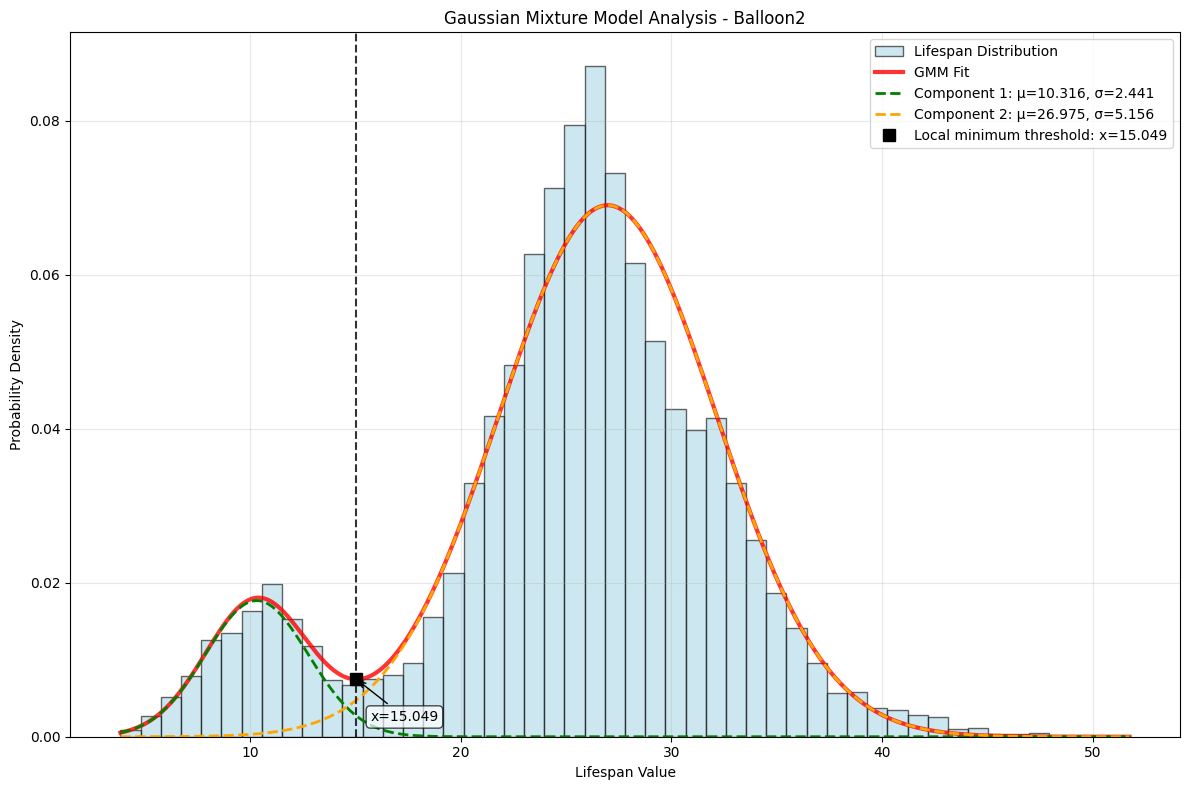


Processing scene: Jumping
tensor(19.0624)


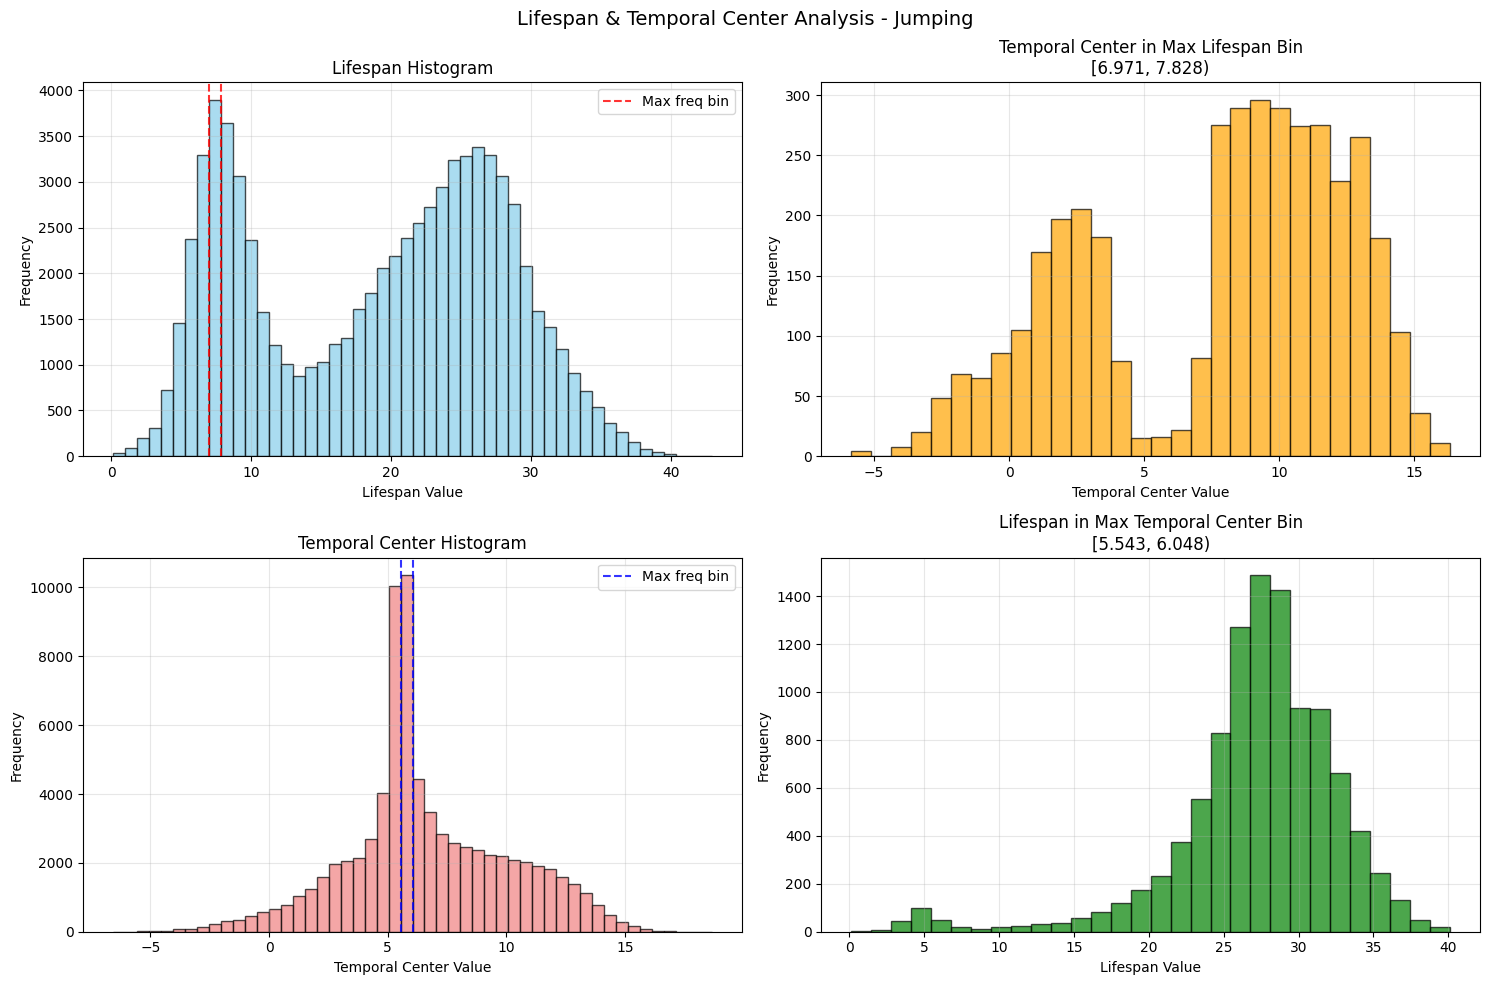

Local minimum between means: x=13.9006, pdf=0.010220


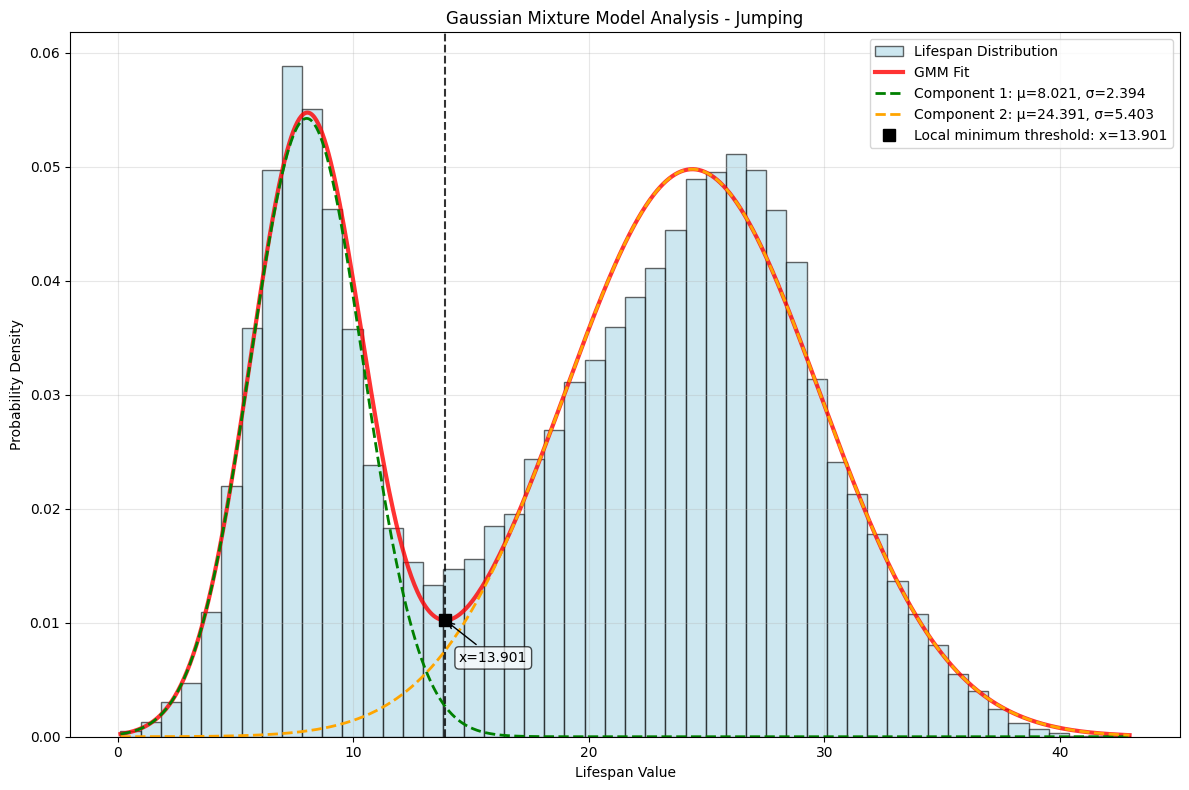


Processing scene: Truck
tensor(24.7762)


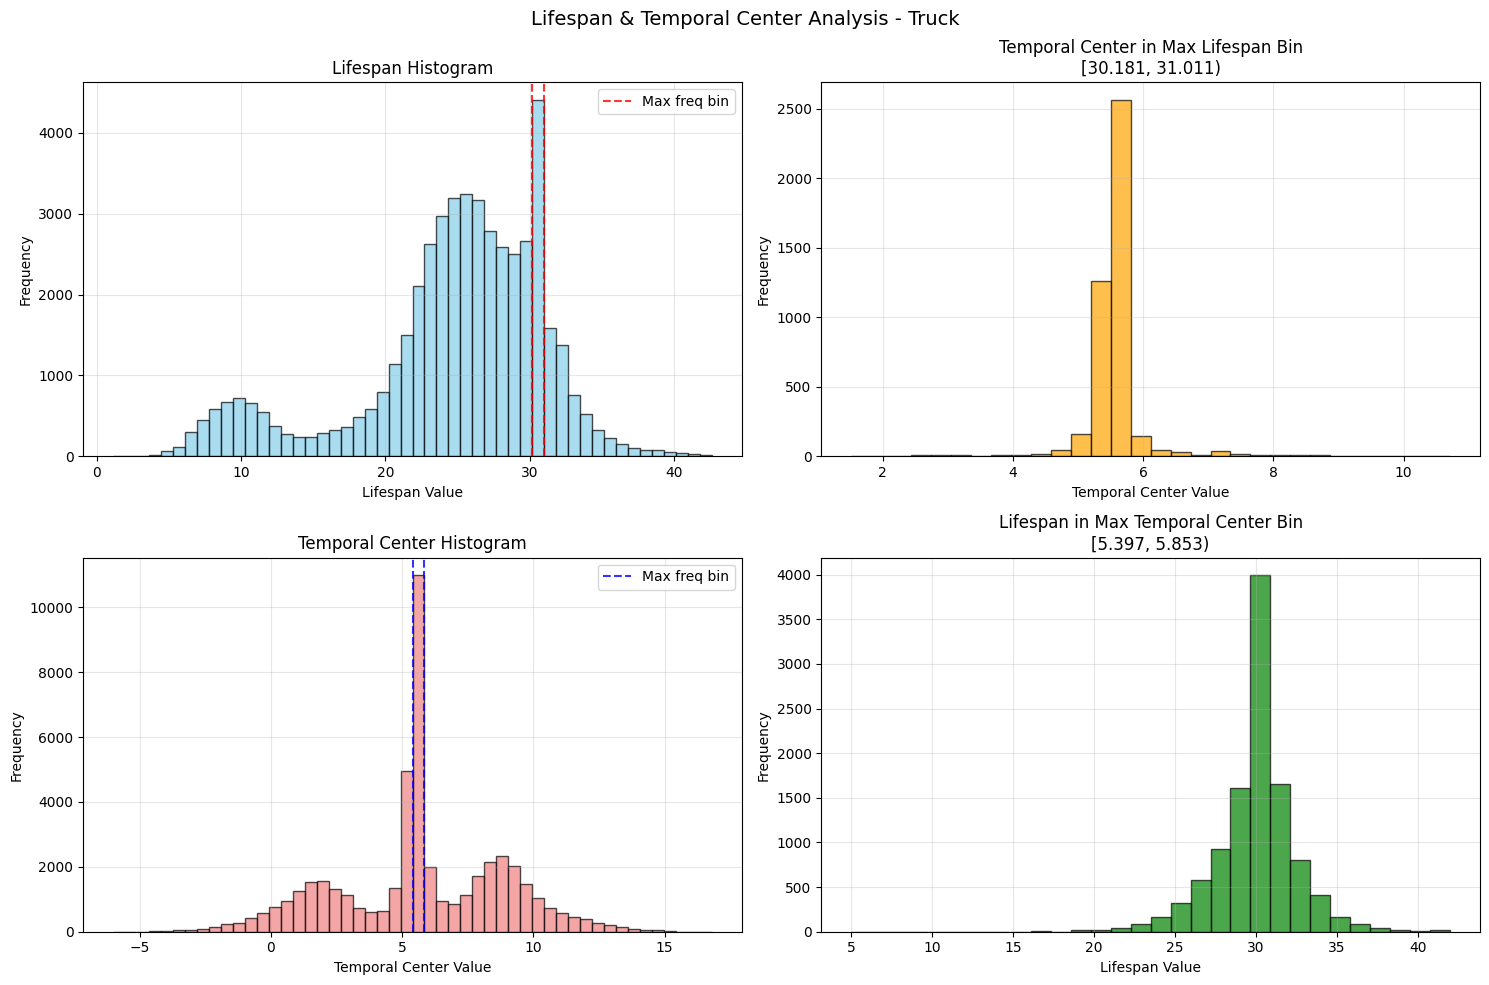

Local minimum between means: x=15.5779, pdf=0.004847


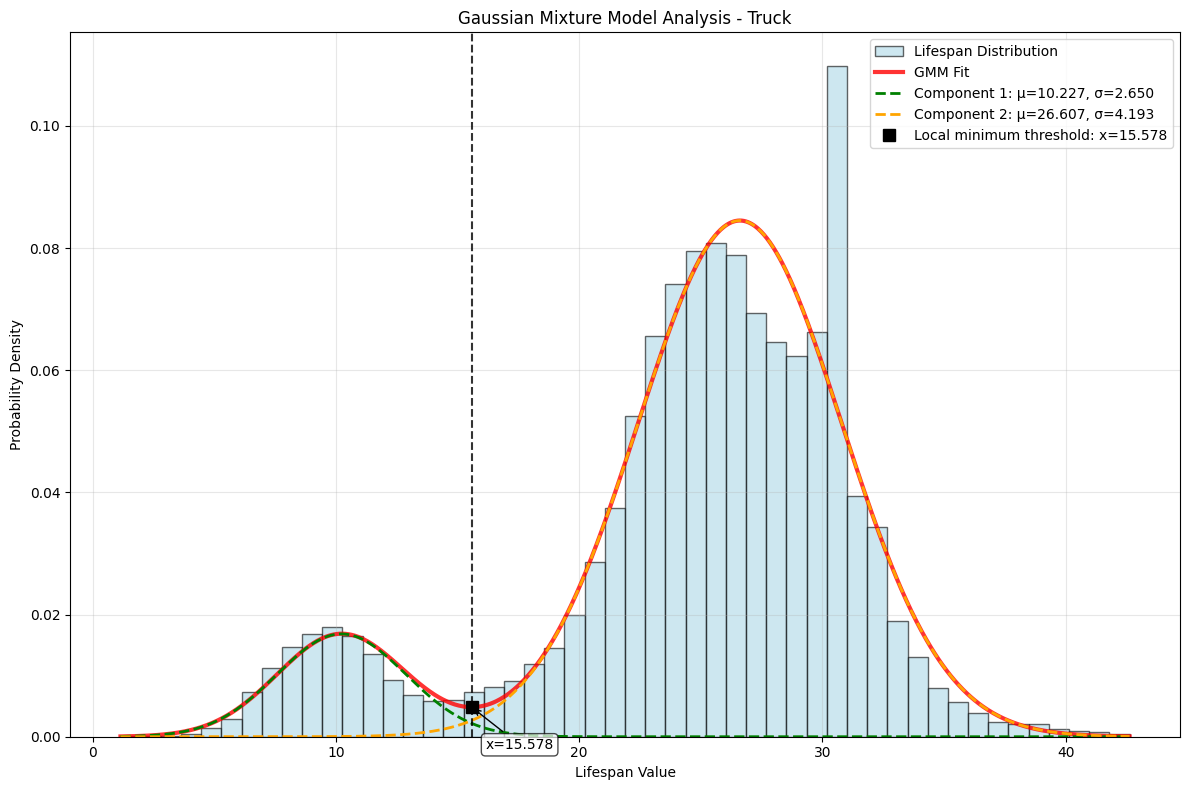


Processing scene: Umbrella
tensor(14.6515)


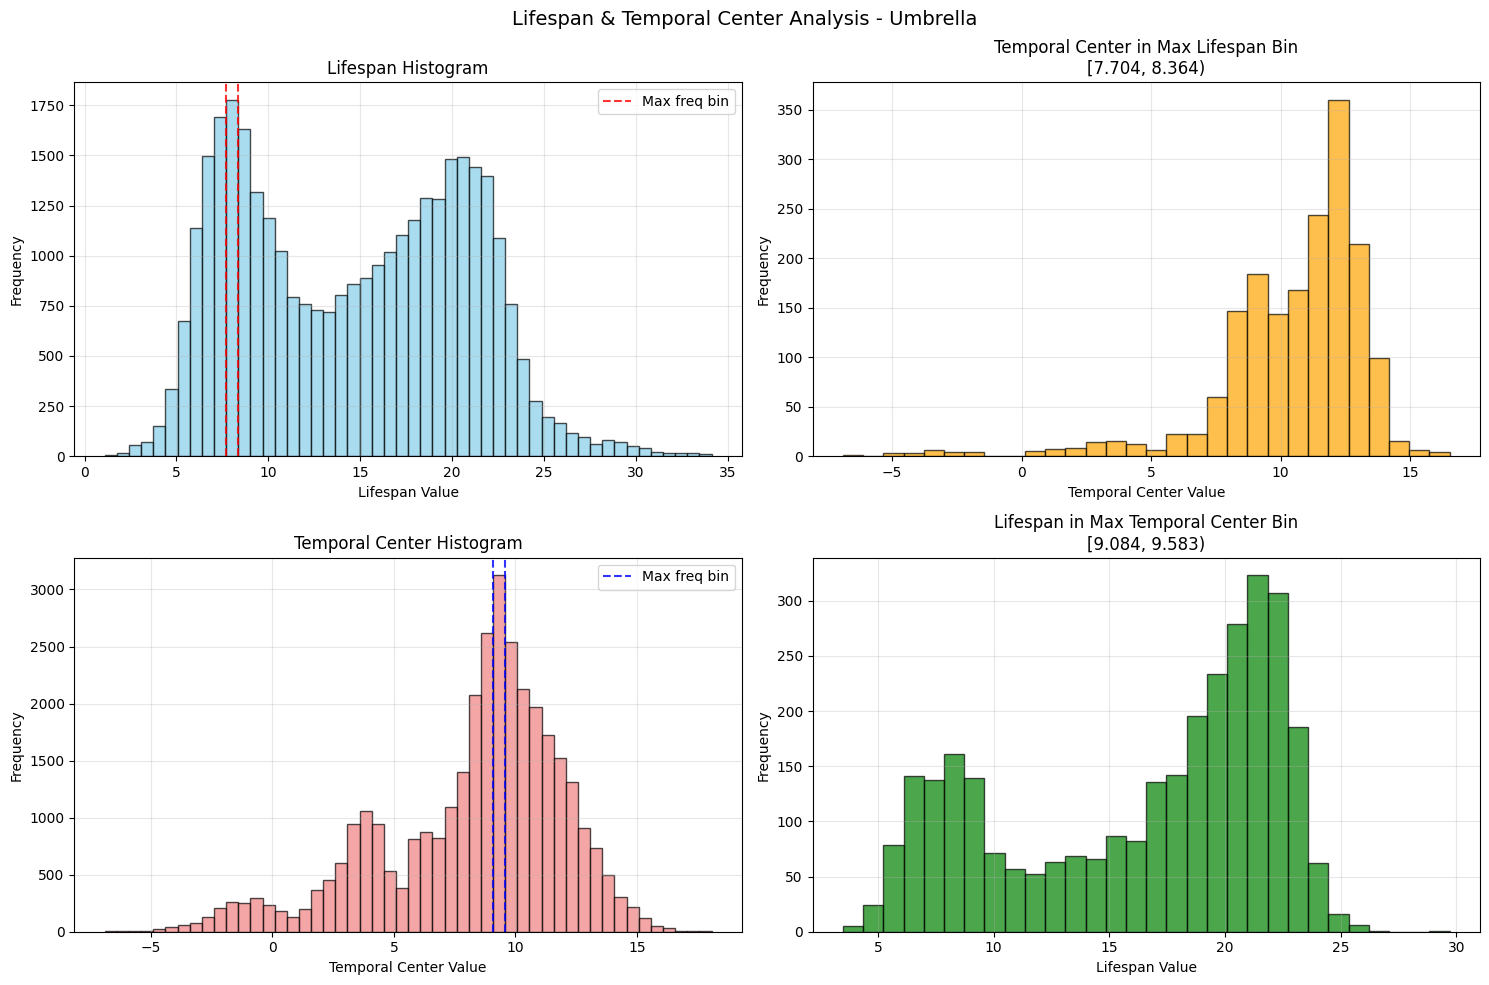

Local minimum between means: x=13.2017, pdf=0.026070


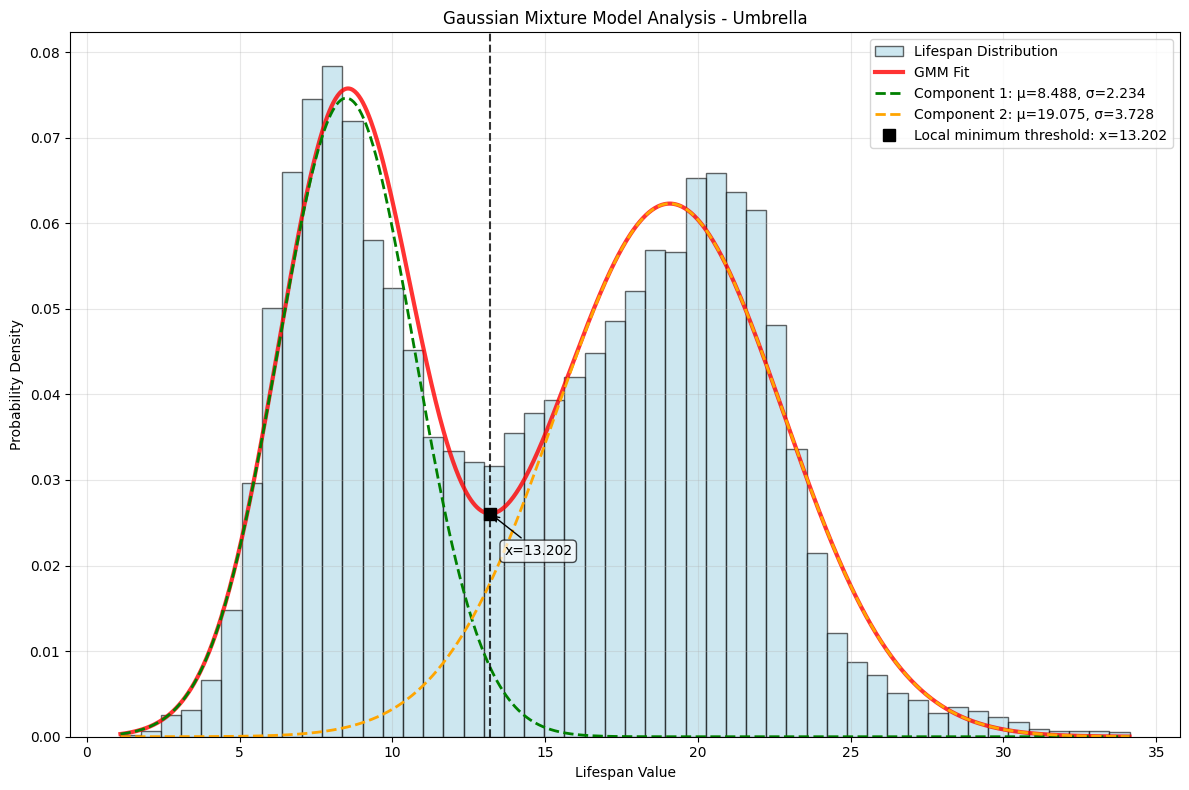

Checkpoint not found: /n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_wo_transient/TPGS/results_nvidia_wo_transient/ours_playground_4.png/ckpts/ckpt_29999.pt
Checkpoint not found: /n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_wo_transient/TPGS/results_nvidia_wo_transient/umbrella_4.png/ckpts/ckpt_29999.pt

Processing scene: Balloon1
tensor(13.1903)


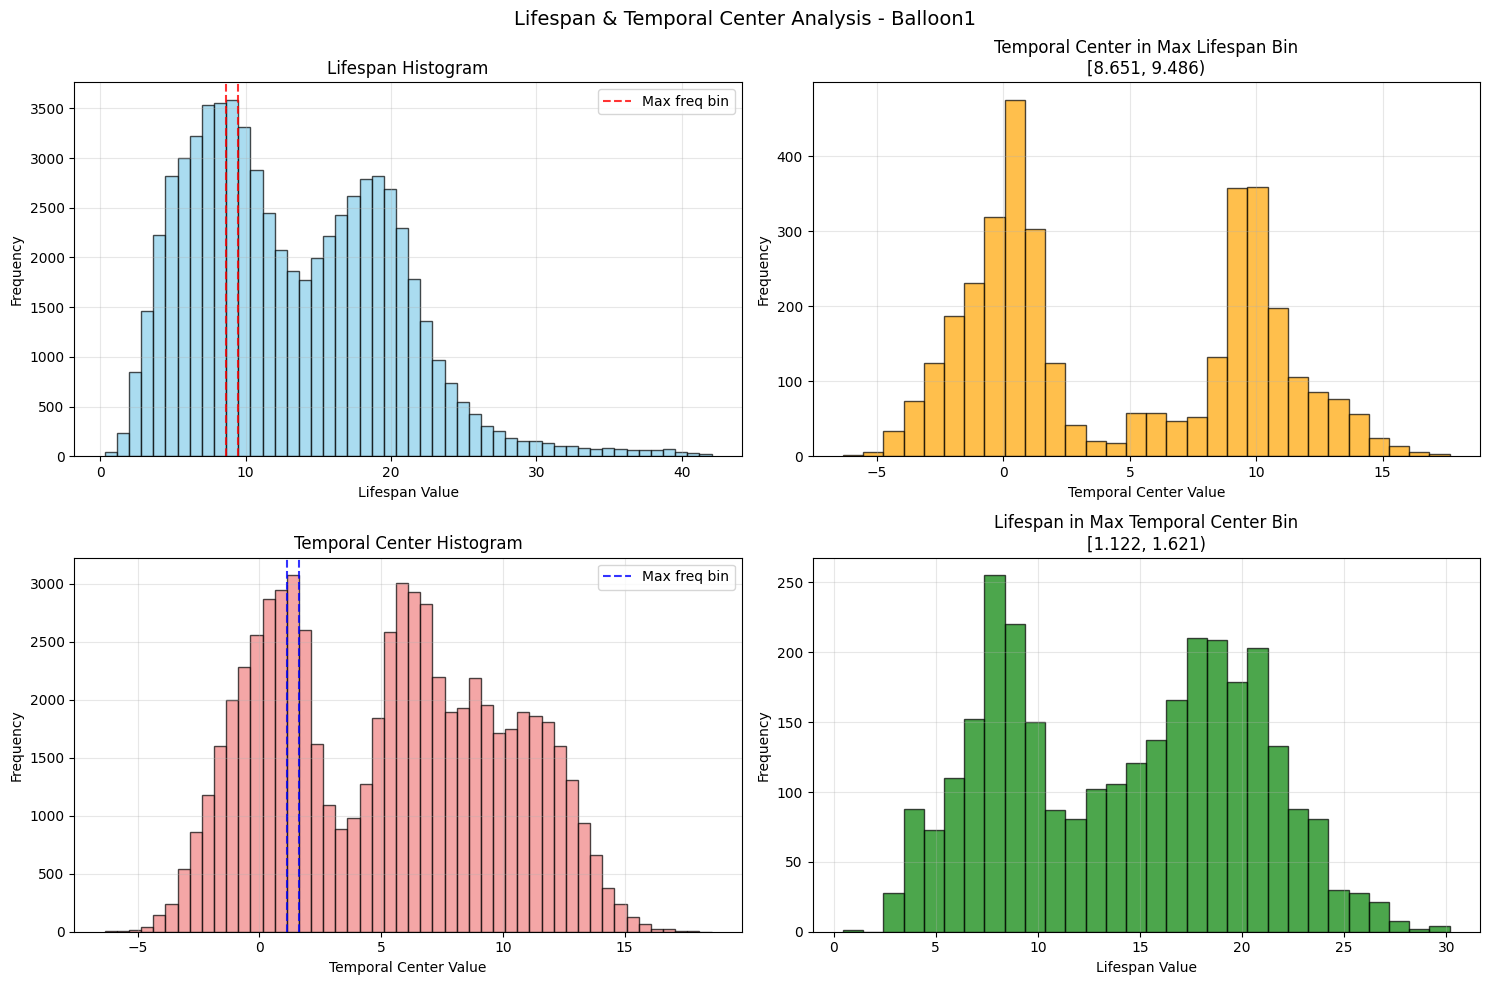

Local minimum between means: x=13.8161, pdf=0.035876


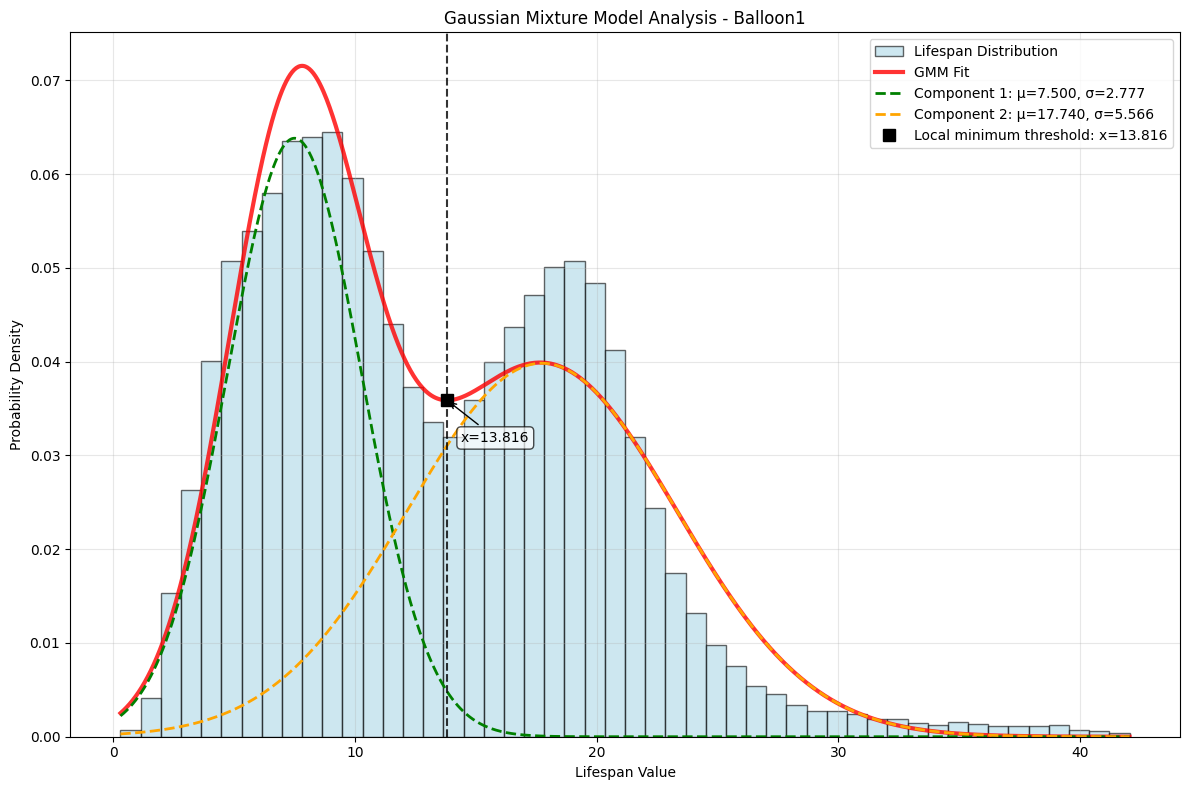

In [4]:
for scene in scene_names:
    ckpt_path = os.path.join(result_dir, scene, "ckpts", "ckpt_29999.pt")
    if os.path.exists(ckpt_path):
        print(f"\nProcessing scene: {scene}")
        ckpt = torch.load(ckpt_path, map_location="cpu")
        # lifespan = torch.nn.functional.softplus(ckpt["dynamic_splats"]["lifespan_p"])
        lifespan = ckpt["dynamic_splats"]["lifespan"]
        print(lifespan.mean())
        temporal_center = ckpt["dynamic_splats"]["temporal_center"]
        analyze_lifespan_with_temporal_center(lifespan, temporal_center, scene_name=scene)
    else:
        print(f"Checkpoint not found: {ckpt_path}")

In [4]:
ckpt_path = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/results/paper_windmill/ckpts/ckpt_14999.pt"
# ckpt_path = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/results/Balloon1/ckpts/ckpt_29999.pt"
ckpt = torch.load(ckpt_path, map_location="cpu")
lifespan = ckpt["dynamic_splats"]["lifespan"]
temporal_center = ckpt["dynamic_splats"]["temporal_center"]
analyze_lifespan_with_temporal_center(lifespan, temporal_center, scene_name="test")

FileNotFoundError: [Errno 2] No such file or directory: '/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/TPGS/results/paper_windmill/ckpts/ckpt_14999.pt'

In [ ]:
result_dir = "/n/holylfs05/LABS/pfister_lab/Lab/coxfs01/pfister_lab2/Lab/chenyuwu/project/test_ground/nvidia_w_flow_lifespan_alpha/TPGS/results_nvidia_w_flow_lifespan_alpha"
for scene in scene_names:
    ckpt_path = os.path.join(result_dir, scene, "ckpts", "ckpt_29999.pt")
    if os.path.exists(ckpt_path):
        print(f"\nProcessing scene: {scene}")
        ckpt = torch.load(ckpt_path, map_location="cpu")
        lifespan = ckpt["dynamic_splats"]["lifespan"]
        temporal_center = ckpt["dynamic_splats"]["temporal_center"]
        analyze_lifespan_with_temporal_center(lifespan, temporal_center, scene_name=scene)
    else:
        print(f"Checkpoint not found: {ckpt_path}")